# 异常值分析

In [1]:
import pandas as pd

## 读取原始数据

In [2]:
file_path = '../data/raw/sales_data.csv'
df = pd.read_csv(file_path, parse_dates=['Date'])
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## 描述性统计对比

In [3]:
df.groupby('Promotion')['Units Sold'].describe()

,count,mean,std,min,25%,50%,75%,max
Promotion,,,,,,,,
0,51000.0,81.833314,39.180915,0.0,54.0,78.0,105.0,291.0
1,25000.0,103.095080,49.487429,0.0,69.0,98.0,131.0,426.0


初步结论：促销日销量整体显著高于非促销日，且波动更大，可能存在合理异常值

## 正态性检验（Shapiro-Wilk 方法）

In [ ]:
from scipy.stats import shapiro

In [12]:
# 全量数据检验
print(shapiro(df[df['Promotion'] == 0]['Units Sold']))
print(shapiro(df[df['Promotion'] == 1]['Units Sold']))

ShapiroResult(statistic=0.9775268383924298, pvalue=2.07369450681662e-63)
ShapiroResult(statistic=0.9749658004595619, pvalue=3.370044967642244e-53)


In [13]:
# 抽样数据检验
print(shapiro(df[df['Promotion'] == 0]['Units Sold'].sample(500)))
print(shapiro(df[df['Promotion'] == 1]['Units Sold'].sample(500)))

ShapiroResult(statistic=0.9645845560591368, pvalue=1.2930024663232333e-09)
ShapiroResult(statistic=0.977787556987608, pvalue=6.672479101398362e-07)


若 p-value < 0.05，则拒绝正态性假设，使用非参数检验（如 Mann-Whitney U 检验）  
若 p-value ≥ 0.05，则接受正态性假设，使用 t 检验

## Mann-Whitney U 检验

In [14]:
from scipy.stats import mannwhitneyu
mannwhitneyu(df[df['Promotion'] == 1]['Units Sold'],
             df[df['Promotion'] == 0]['Units Sold'],
             alternative='greater')

MannwhitneyuResult(statistic=803224495.0, pvalue=0.0)

✅ 结论：促销日销量显著高于非促销日，差异具有统计学意义。

## 📊 可视化销量分布差异

### 箱线图

<Axes: xlabel='Promotion', ylabel='Units Sold'>

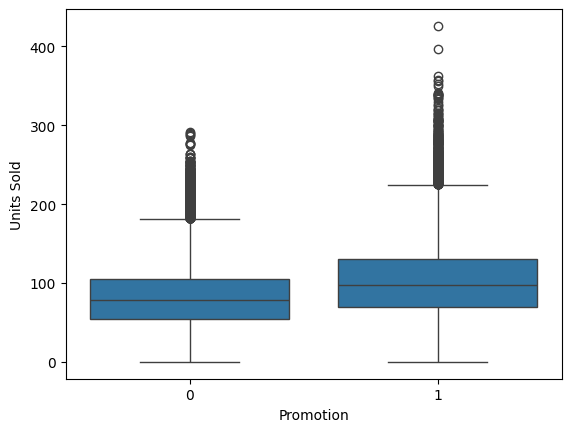

In [15]:
import seaborn as sns
sns.boxplot(x='Promotion', y='Units Sold', data=df)

### KDE 密度图

<Axes: xlabel='Units Sold', ylabel='Density'>

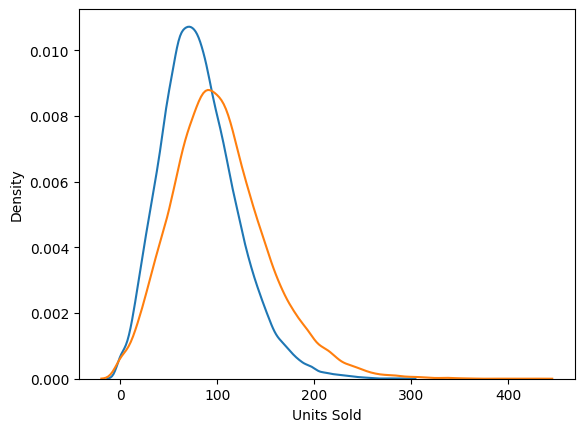

In [16]:
sns.kdeplot(df[df['Promotion'] == 0]['Units Sold'], label='非促销日')
sns.kdeplot(df[df['Promotion'] == 1]['Units Sold'], label='促销日')

### 时间序列图

<Axes: xlabel='Date', ylabel='Units Sold'>

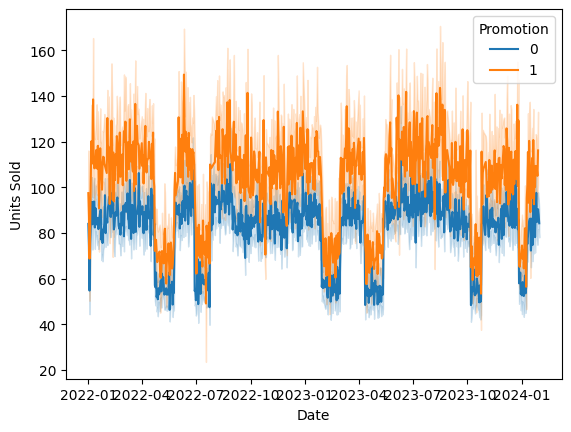

In [17]:
sns.lineplot(x='Date', y='Units Sold', hue='Promotion', data=df.sort_values('Date'))

In [9]:
# 以促销日销量的 95% 分位数作为阈值
threshold = df[df['Promotion'] == 1]['Units Sold'].quantile(0.95)

<Axes: title={'center': 'Monthly Anomaly Days'}, xlabel='Date'>

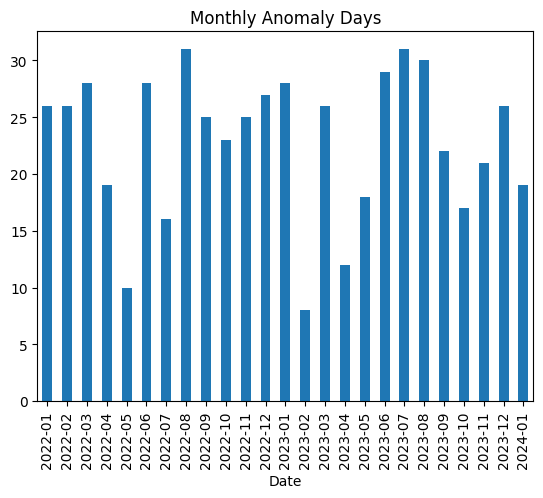

In [16]:
df['Anomaly Flag'] = (df['Units Sold'] > threshold).astype(int)
anomaly_days = df[df['Anomaly Flag'] == 1]['Date'].drop_duplicates()
anomaly_calendar = anomaly_days.groupby(anomaly_days.dt.to_period('M')).size()
anomaly_calendar.plot(kind='bar', title='Monthly Anomaly Days')